In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot


In [ ]:
# STEP 2: Load the Dataset

df = pd.read_csv("/content/diabetes (1).csv")

print("First 5 rows of dataset:")
print(df.head())

# Check column names
print(df.columns)

First 5 rows of dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [ ]:
X = df.drop("Outcome", axis=1)   # Independent variables (all except target)
y = df["Outcome"]                # Dependent variable (target)

# Add constant term for OLS
X = sm.add_constant(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (614, 9)
Testing set shape: (154, 9)


In [ ]:
model = sm.OLS(y_train, X_train)

# Fit the model
results = model.fit()

print("\nOLS Regression Results Summary:")
print(results.summary())


OLS Regression Results Summary:
                            OLS Regression Results                            
Dep. Variable:                Outcome   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.296
Method:                 Least Squares   F-statistic:                     33.20
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           2.10e-43
Time:                        12:08:41   Log-Likelihood:                -303.68
No. Observations:                 614   AIC:                             625.4
Df Residuals:                     605   BIC:                             665.1
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

In [ ]:
y_pred = results.predict(X_test)

print("\nFirst 5 Predictions:")
print(y_pred.head())


First 5 Predictions:
668    0.335500
324    0.238099
624    0.151052
690    0.240136
473    0.481424
dtype: float64


In [ ]:
# Residual = Actual - Predicted
residuals = y_test - y_pred

<Figure size 600x600 with 0 Axes>

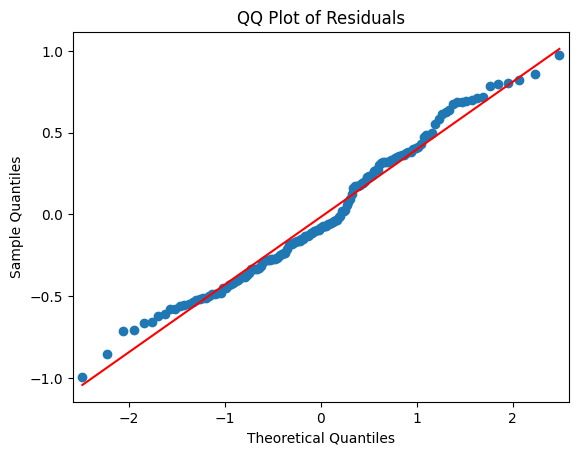

In [ ]:
plt.figure(figsize=(6,6))

# QQ plot compares residual distribution with normal distribution
qqplot(residuals, line='s')

plt.title("QQ Plot of Residuals")
plt.show()

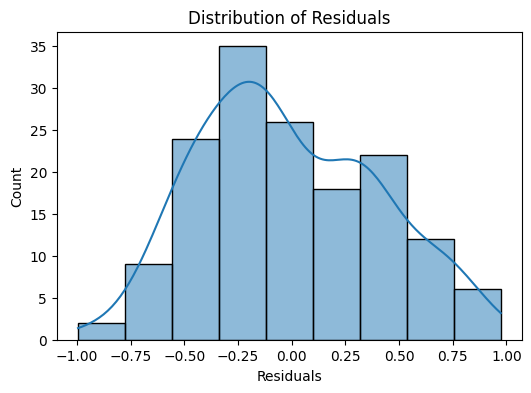

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.show()

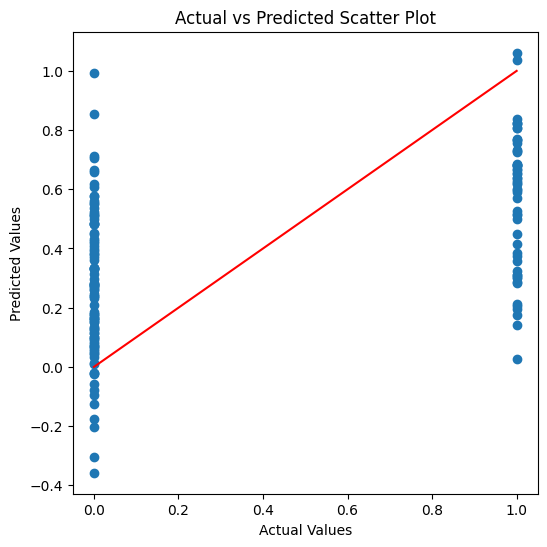

In [ ]:
plt.figure(figsize=(6,6))

# Plotting actual values on x-axis and predicted values on y-axis
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Scatter Plot")
plt.show()